In [ ]:
# !pip install tensorflow[and-cuda]

##### **Generate Regression Data: (Continuous Data)**

In [2]:
from sklearn.datasets import make_regression

# generate a random regression problem
X, y = make_regression(n_samples=1000, n_features=150, n_informative=10 ,noise=0.1, random_state=1)


##### **Preprocessing:**

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [7]:
# Split the dataset:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.34, random_state=1)

processor = MinMaxScaler()

processor.fit(x_train)
x_train = processor.transform(x_train)
x_test = processor.transform(x_test)

##### **Building the model (AutoEncoder):: Encoder & Decoder**

##### **Encoder:**

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, ReLU, BatchNormalization, Dropout

inputs = x_train.shape[1]

#define the encoder
encoder_input = Input(shape=(inputs,))
encoder_layer = Dense(inputs*2)(encoder_input)
encoder_layer = BatchNormalization()(encoder_layer)
encoder_layer = ReLU()(encoder_layer)

# define the end of the encoder:: the bottleNeck layer:
inputs_bottleNeck = inputs
bottleNeck_layer = Dense(inputs_bottleNeck)(encoder_layer)

##### **Decoder:**

In [20]:
# Define the decoder
decoder = Dense(inputs*2)(bottleNeck_layer)
decoder = BatchNormalization()(decoder)
decoder = ReLU()(decoder)
decoder_output = Dense(inputs, activation='linear')(decoder)

# define the autoencoder model
autoencoder = Model(inputs= encoder_input, outputs=decoder_output)

##### **Complining & Configuration:**

In [21]:
autoencoder.compile(optimizer='adam', loss='mse')

#### **Plot The Autoencoder:**

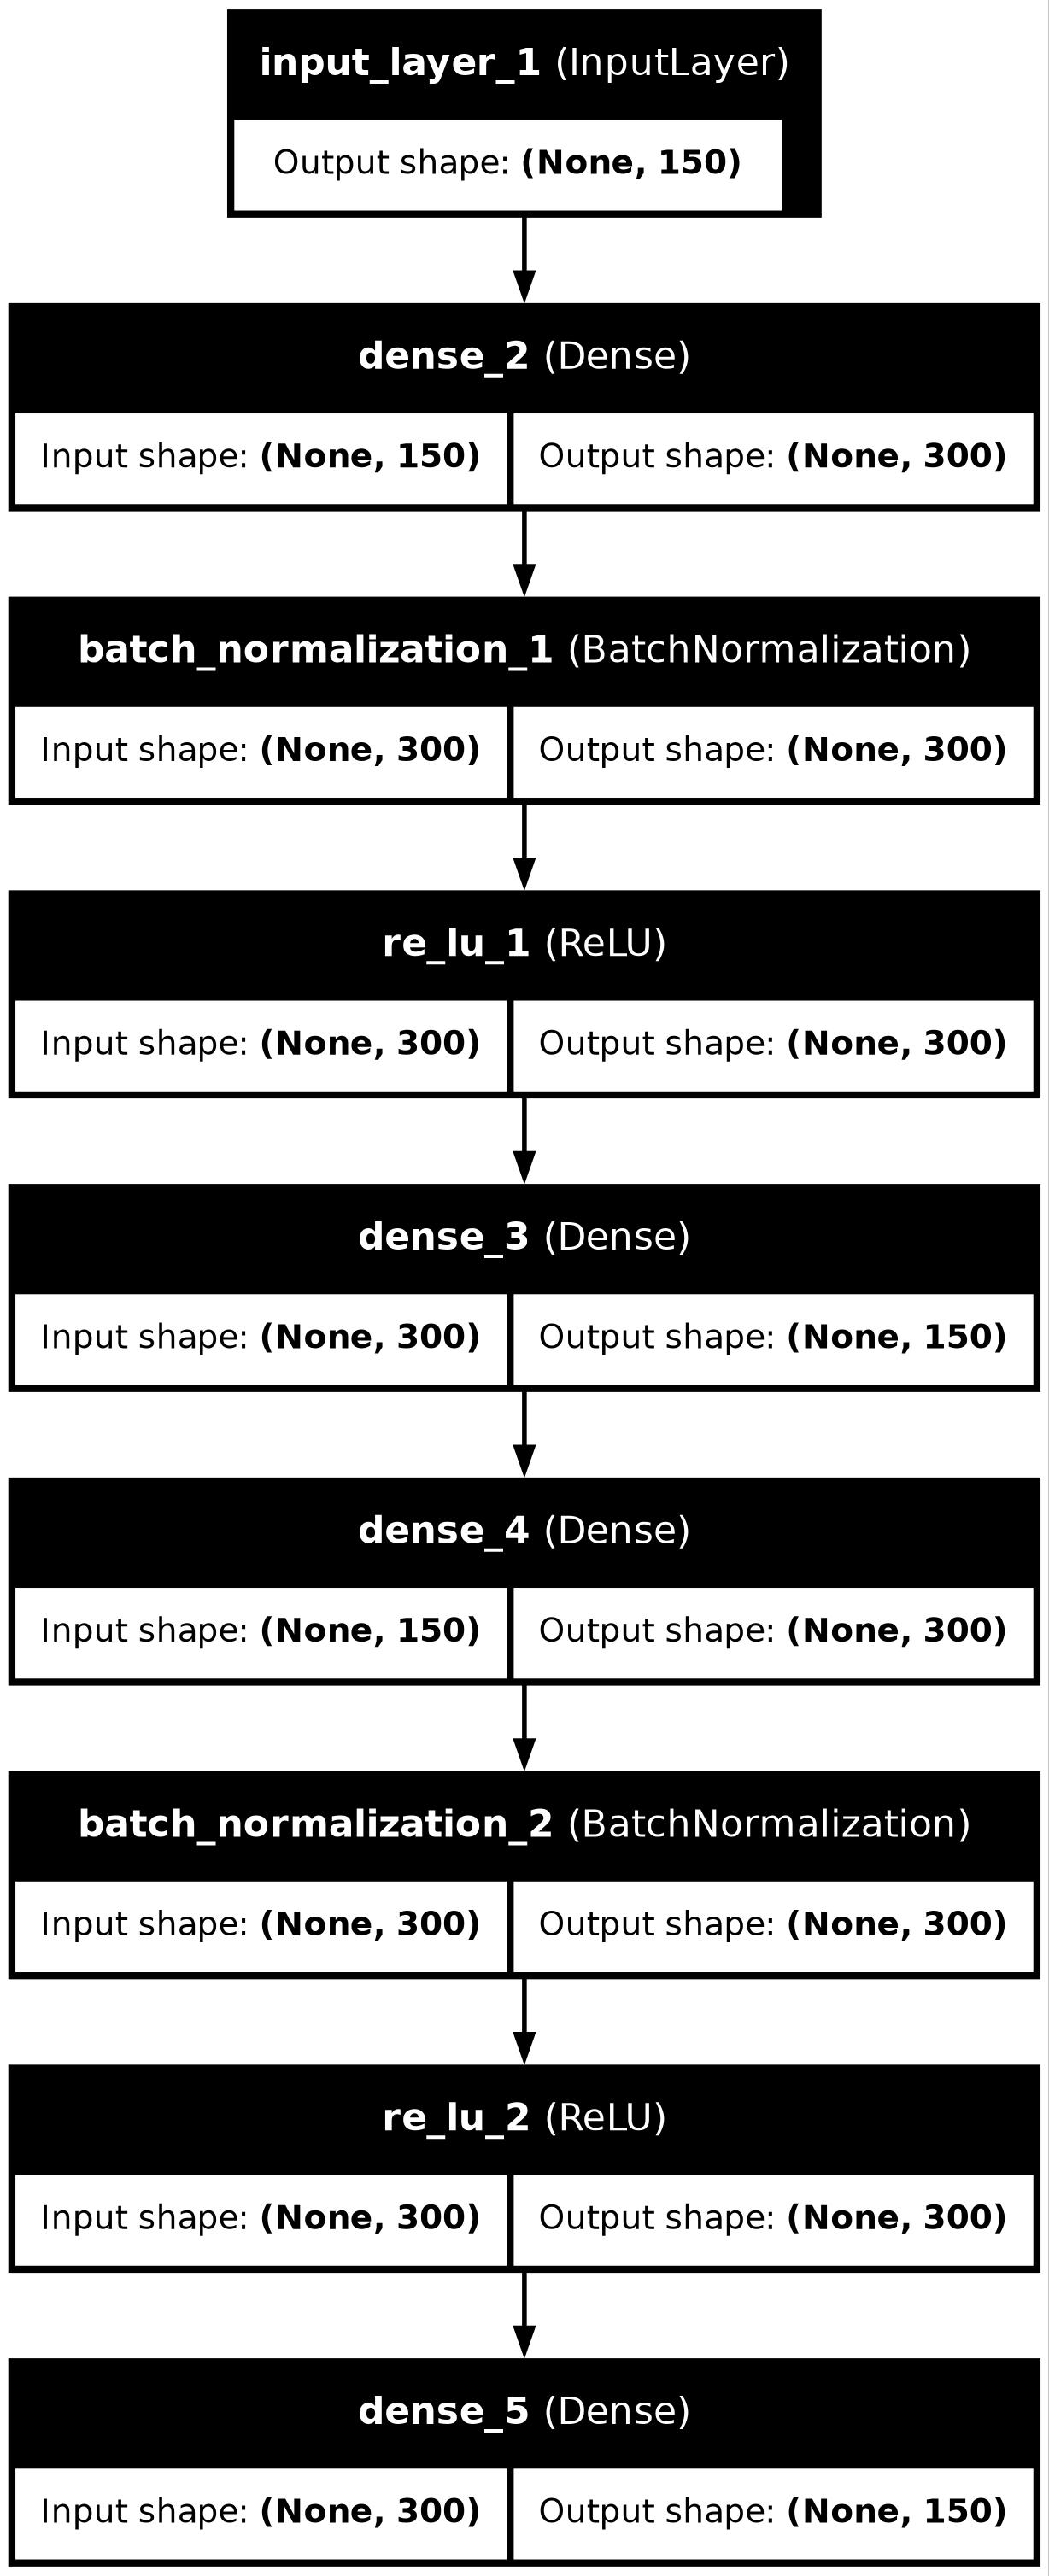

In [27]:


from tensorflow.keras.utils import plot_model
plot_model(autoencoder,'autoencoder.jpg', show_shapes=True, show_layer_names=True)

##### **Train the AutoEncoder:**

In [28]:
history = autoencoder.fit(x_train, x_train, epochs=500,validation_data=(x_test, x_test))

Epoch 1/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4397 - val_loss: 0.1750
Epoch 2/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1733 - val_loss: 0.1777
Epoch 3/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1123 - val_loss: 0.1658
Epoch 4/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0865 - val_loss: 0.1485
Epoch 5/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0716 - val_loss: 0.1327
Epoch 6/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0613 - val_loss: 0.1154
Epoch 7/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0538 - val_loss: 0.1053
Epoch 8/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0477 - val_loss: 0.0947
Epoch 9/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0429 - val_loss: 0.0846
Epoch 10/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0392 - val_loss: 0.0784
Epoch 11/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0361 - val_loss: 0.0728
Epoch 12/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0

##### **Plot the losses to see match:**

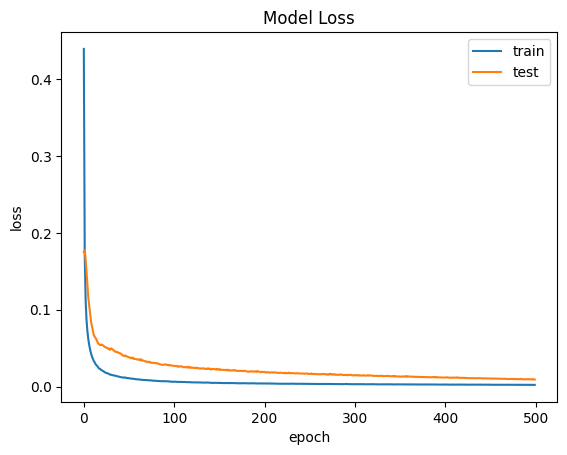

In [29]:
from matplotlib import pyplot as plt

plt.title('Model Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

##### **Split the encoder from the autoencoder:**

In [31]:
enc = Model(inputs=encoder_input, outputs=bottleNeck_layer)

##### **Plot the encoder:**

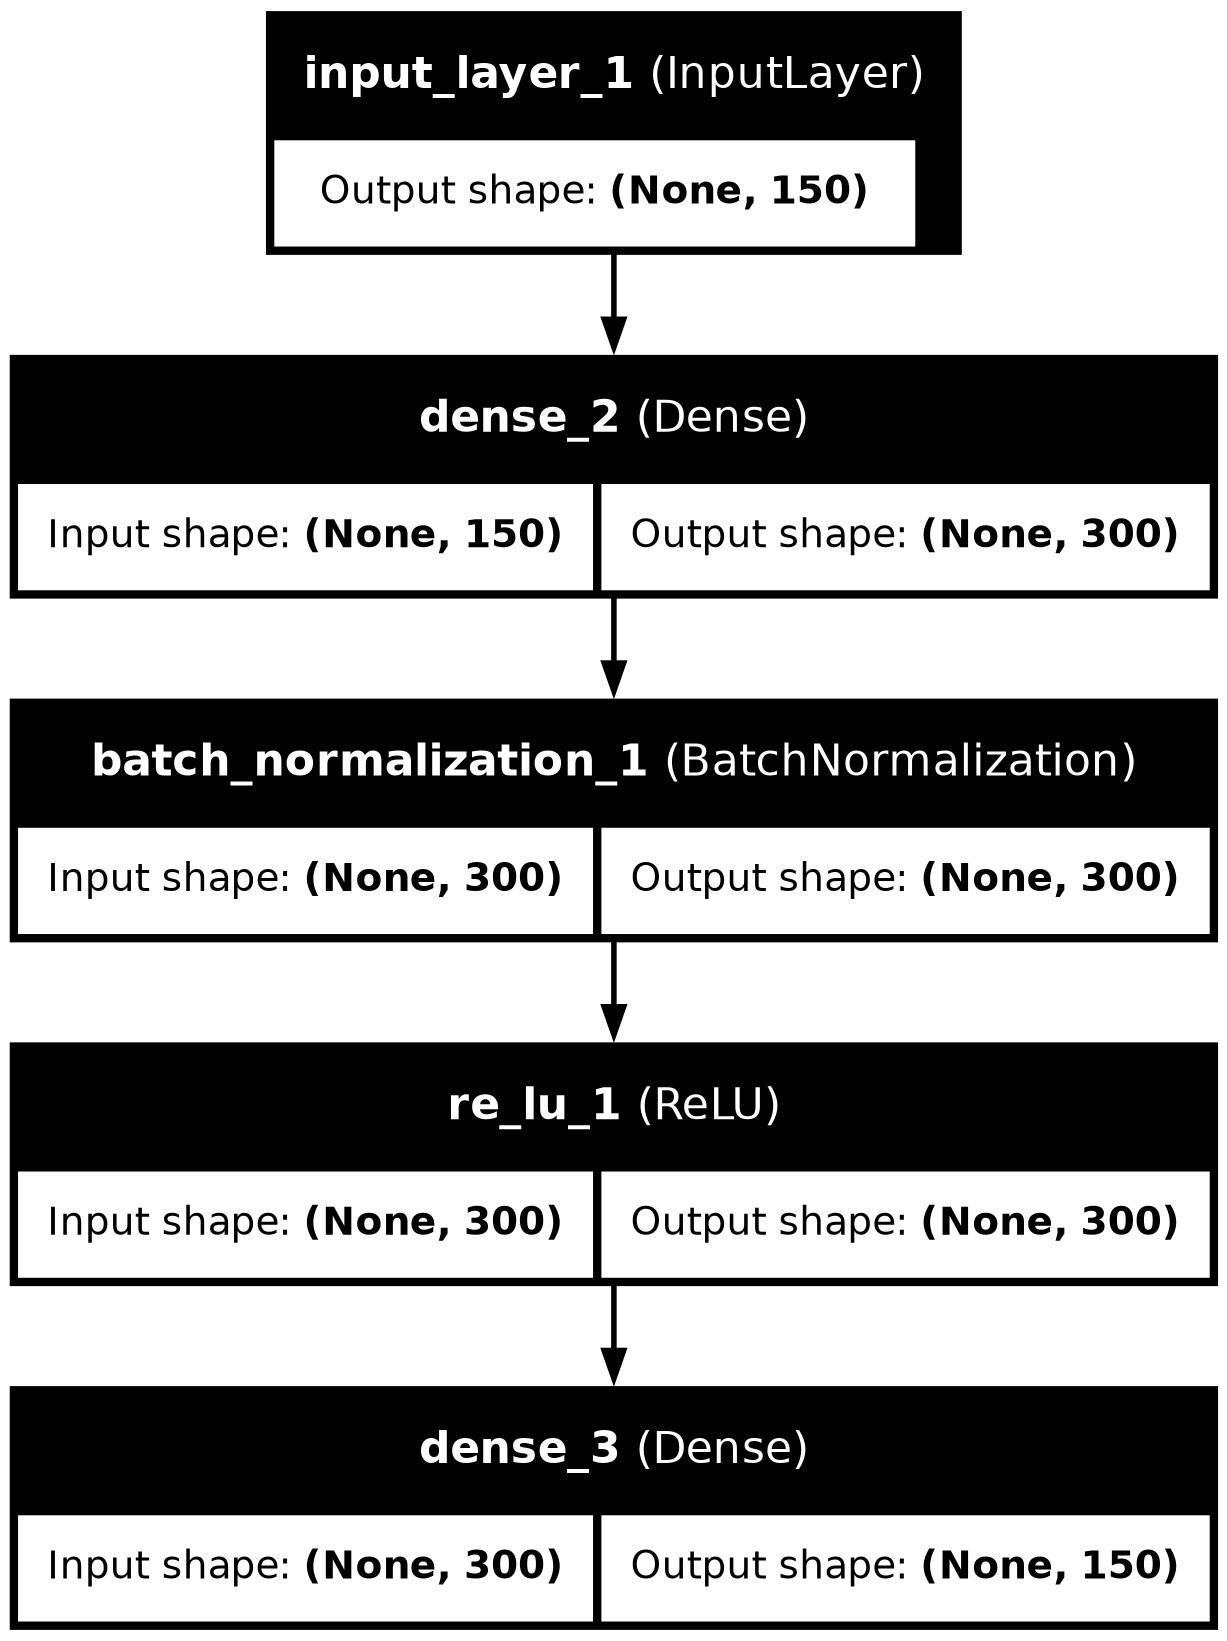

In [32]:
plot_model(enc,'encoder.jpg', show_shapes=True, show_layer_names=True)